En este trabajo se analizó el dataset de órdenes de compra del Municipio de Bahía Blanca correspondiente al ejercicio 2024, publicado en el portal de datos abiertos municipal. El objetivo fue construir un modelo de regresión lineal capaz de predecir el importe de una orden de compra a partir de las variables disponibles en el conjunto de datos.

In [1]:
import pandas as pd

df = pd.read_csv("ordenes_de_compras_municipales-2024.csv")

la variable fecha fue convertida al tipo datetime para facilitar comparaciones temporales. Luego, se filtraron los registros correspondientes a la fecha y proveedor. Finalmente, se presentó la información encontrada en un formato más legible, mostrando únicamente las variables relevantes para la validación: fecha, proveedor, dependencia, número de orden e importe. 

In [2]:

# Convertir fecha correctamente
df["fecha"] = pd.to_datetime(
    df["fecha"],
    format="%d-%m-%Y"
)

# Filtrar registros
busqueda = df[
    (df["fecha"] == "2024-08-06") &
    (df["proveedor"].str.contains("NUGGETS", case=False, na=False))
]

# Mostrar resultado prolijo
if not busqueda.empty:

    print("\n=== REGISTROS ENCONTRADOS ===\n")

    columnas_mostrar = [
        "fecha",
        "proveedor",
        "dependencia",
        "importe",
        "ordencompra"
    ]

    for i, (_, fila) in enumerate(busqueda[columnas_mostrar].iterrows(), start=1):

        print(f"Registro #{i}")
        print("-" * 50)
        print(f"Fecha           : {fila['fecha'].date()}")
        print(f"Proveedor       : {fila['proveedor']}")
        print(f"Dependencia     : {fila['dependencia']}")
        print(f"Orden de compra : {fila['ordencompra']}")
        print(f"Importe         : ${fila['importe']:,.2f}")
        print()

else:
    print("No se encontraron registros.")


=== REGISTROS ENCONTRADOS ===

Registro #1
--------------------------------------------------
Fecha           : 2024-08-06
Proveedor       : NUGGETS
Dependencia     : SUBSECR. DE NINEZ, ADOLESC. Y FAMILIA
Orden de compra : 5259
Importe         : $227,601.00



In [3]:
print(df.isnull().sum())

ejercicio      0
ordencompra    0
fecha          0
importe        0
proveedor      0
dependencia    0
expediente     0
dtype: int64


In [4]:
print("Duplicados:", df.duplicated().sum())

Duplicados: 0


se aplicó describe() sobre la variable importe con el objetivo de obtener un resumen estadístico inicial de la variable objetivo. Entre las medidas calculadas se encuentran:

cantidad de registros,
media,
desvío estándar,
valor mínimo,
cuartiles,
valor máximo.

Este análisis permitió observar la fuerte dispersión de los importes y la presencia de valores extremadamente altos en comparación con la mayoría de las órdenes de compra. En consecuencia, se justificó posteriormente el uso de una transformación logarítmica (log_importe) para reducir la asimetría de la distribución y mejorar el comportamiento del modelo de regresión.

In [5]:
df["importe"].describe()

count    8.559000e+03
mean     7.366996e+06
std      1.102961e+08
min      4.200000e+02
25%      2.190050e+05
50%      6.561041e+05
75%      1.696600e+06
max      5.786833e+09
Name: importe, dtype: float64

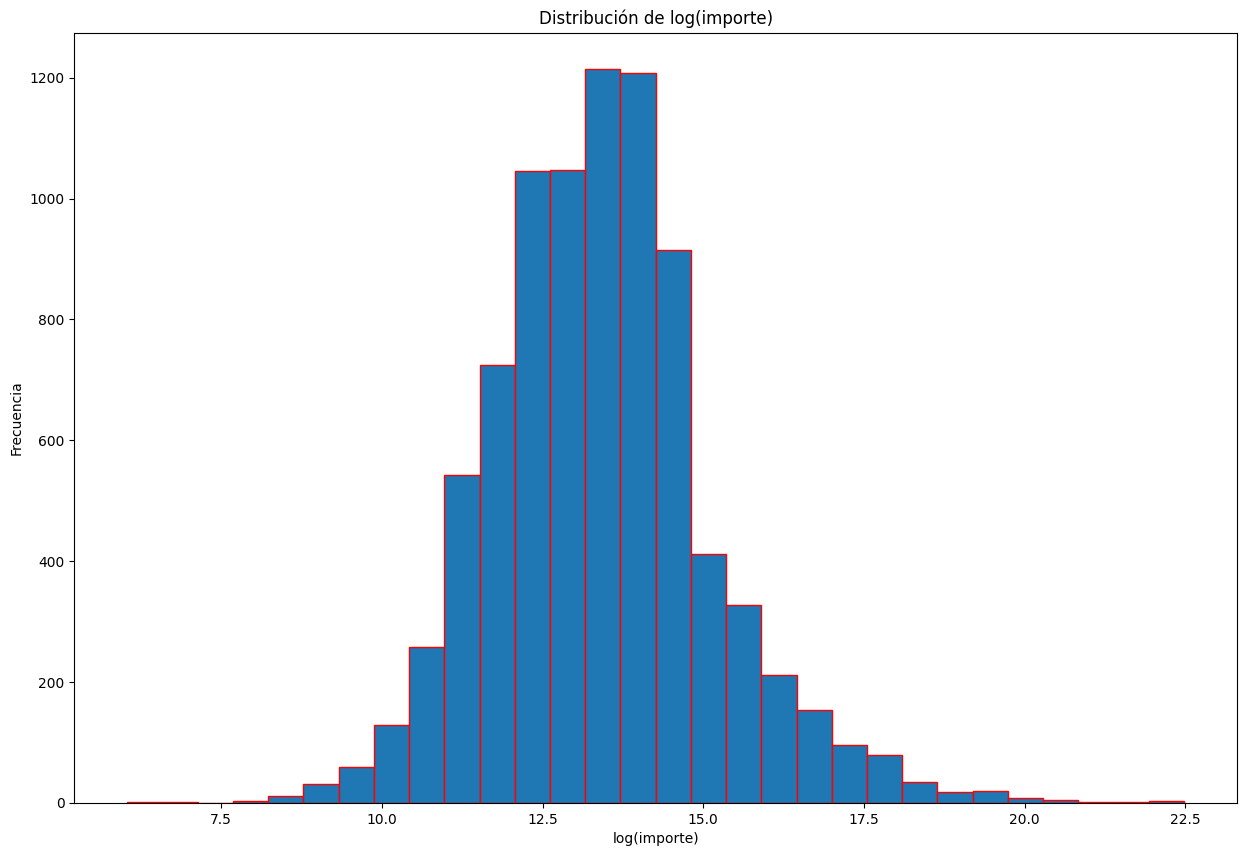

In [6]:
import numpy as np
import matplotlib.pyplot as plt

df["log_importe"] = np.log(df["importe"])

plt.figure(figsize=(15,10))
plt.hist(df["log_importe"], bins=30, edgecolor='red')

plt.xlabel("log(importe)")
plt.ylabel("Frecuencia")
plt.title("Distribución de log(importe)")
plt.show()

log(importe)

Esto se hace porque los importes tienen valores muy dispersos y extremadamente grandes. El logaritmo “comprime” esos valores altos y hace que la distribución sea más equilibrada.

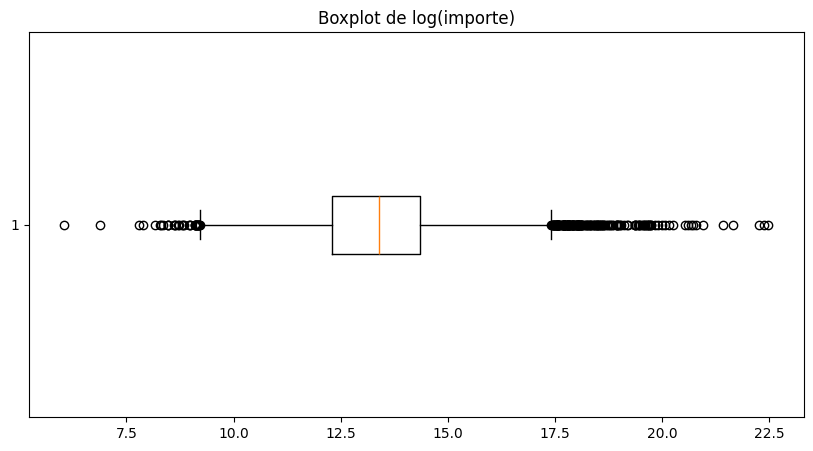

In [7]:
plt.figure(figsize=(10,5))

plt.boxplot(df["log_importe"], vert=False)

plt.title("Boxplot de log(importe)")
plt.show()

In [8]:
# Cuartiles
Q1 = df["log_importe"].quantile(0.25)
Q2 = df["log_importe"].quantile(0.50)  # mediana
Q3 = df["log_importe"].quantile(0.75)

# Rango intercuartílico
IQR = Q3 - Q1

# Límites para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Mediana:", Q2)
print("Q3:", Q3)
print("IQR:", IQR)

print("\nLímite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

# Filtrar outliers
outliers = df[
    (df["log_importe"] < limite_inferior) |
    (df["log_importe"] > limite_superior)
]

print("\nCantidad de outliers:", len(outliers))

Q1: 12.296849839327626
Mediana: 13.394074668153424
Q3: 14.344136743822148
IQR: 2.0472869044945217

Límite inferior: 9.225919482585844
Límite superior: 17.41506710056393

Cantidad de outliers: 221


In [9]:
freq_dep = df["dependencia"].value_counts()

print(freq_dep.head(20))

dependencia
DEPARTAMENTO TALLERES Y MAESTRANZA                  733
INSTITUTO CULTURAL MUNICIPAL                        667
SEC. DE SALUD                                       604
INTENDENCIA                                         563
H.C.D.                                              278
INSTITUTO DEL DEPORTE                               249
SUBSECR. DE NINEZ, ADOLESC. Y FAMILIA               239
DIV. DE CONTROL Y ORDENAMIENTO URBANO               217
DIRECCION GENERAL DE EDUCACION                      202
DEP. PROYECTOS Y OBRAS                              193
SUBSECRETARIA DE AMBIENTE                           151
DEP. MANTENIMIENTO DE ALUMBRADO PUBLICO             144
SEC. DE OBRAS Y SERVICIOS PUBLICOS                  143
SUBSECRETARIA DE PROTECCION CIUDADANA               135
DIVISION DESARROLLO SOCIAL                          129
SUBSECRETARIA RELACIONES INSTITUCIONALES Y CULTO    117
DEP. ELECTRICIDAD Y MECANICA                        107
SUBSECRETARIA DE HABITAT            

In [10]:
# Frecuencia relativa acumulada
acumulada = (
    freq_dep.cumsum() / freq_dep.sum()
)

print(acumulada.head(30))

dependencia
DEPARTAMENTO TALLERES Y MAESTRANZA                   0.085641
INSTITUTO CULTURAL MUNICIPAL                         0.163571
SEC. DE SALUD                                        0.234140
INTENDENCIA                                          0.299918
H.C.D.                                               0.332399
INSTITUTO DEL DEPORTE                                0.361491
SUBSECR. DE NINEZ, ADOLESC. Y FAMILIA                0.389415
DIV. DE CONTROL Y ORDENAMIENTO URBANO                0.414768
DIRECCION GENERAL DE EDUCACION                       0.438369
DEP. PROYECTOS Y OBRAS                               0.460918
SUBSECRETARIA DE AMBIENTE                            0.478561
DEP. MANTENIMIENTO DE ALUMBRADO PUBLICO              0.495385
SEC. DE OBRAS Y SERVICIOS PUBLICOS                   0.512093
SUBSECRETARIA DE PROTECCION CIUDADANA                0.527865
DIVISION DESARROLLO SOCIAL                           0.542937
SUBSECRETARIA RELACIONES INSTITUCIONALES Y CULTO     0.556

Luego de analizar la frecuencia acumulada de las dependencias municipales, se decidió reducir la cantidad de categorías presentes en la variable dependencia.

Para ello, se calculó cuántas categorías eran necesarias para cubrir aproximadamente el 60% de las órdenes de compra registradas en el dataset. El análisis mostró que las 20 dependencias más frecuentes concentraban gran parte de las observaciones, mientras que el resto aparecía con frecuencias considerablemente menores.

A partir de este criterio, se seleccionaron las 20 dependencias con mayor cantidad de registros:

In [11]:
N = (acumulada < 0.61).sum()

print("Cantidad de categorías para cubrir 60%:", N)

Cantidad de categorías para cubrir 60%: 20


In [12]:
N = 20

top_dependencias = freq_dep.head(N).index

df["dependencia_reducida"] = df["dependencia"].apply(
    lambda x: x if x in top_dependencias else "Otras"
)

In [13]:
print(df["dependencia_reducida"].value_counts())

dependencia_reducida
Otras                                               3396
DEPARTAMENTO TALLERES Y MAESTRANZA                   733
INSTITUTO CULTURAL MUNICIPAL                         667
SEC. DE SALUD                                        604
INTENDENCIA                                          563
H.C.D.                                               278
INSTITUTO DEL DEPORTE                                249
SUBSECR. DE NINEZ, ADOLESC. Y FAMILIA                239
DIV. DE CONTROL Y ORDENAMIENTO URBANO                217
DIRECCION GENERAL DE EDUCACION                       202
DEP. PROYECTOS Y OBRAS                               193
SUBSECRETARIA DE AMBIENTE                            151
DEP. MANTENIMIENTO DE ALUMBRADO PUBLICO              144
SEC. DE OBRAS Y SERVICIOS PUBLICOS                   143
SUBSECRETARIA DE PROTECCION CIUDADANA                135
DIVISION DESARROLLO SOCIAL                           129
SUBSECRETARIA RELACIONES INSTITUCIONALES Y CULTO     117
DEP. ELECT

In [14]:
freq_prov = df["proveedor"].value_counts()

print(freq_prov.head(20))

proveedor
LA MOLIENDA                                                      193
CODIMAT S.A.                                                     172
AÑOS LUZ                                                         155
ECOBAHIA S.A.                                                    102
FERRETERIA CENTRO                                                 93
ACQUAMANSA                                                        83
PROMAR S.R. L                                                     76
REPUESTOS TATO                                                    69
REPUESTOS LASPIUR                                                 58
ALVAREZ NEUMATICOS S.A.                                           57
DISPROAL                                                          56
CACU CLIMATIZACION                                                51
AQUALIFE                                                          49
LA CASA DEL CARTUCHO - LUIS J. DREVNIAK MATERIALES ELECTRICOS     47
HIPERTEHUELCHE          

El gráfico permitió identificar una fuerte concentración de órdenes en un conjunto reducido de proveedores frecuentes, mientras que la mayoría aparecía pocas veces dentro del dataset. Esta observación justificó posteriormente no utilizar la variable proveedor completa en el modelo, ya que incluir más de mil categorías distintas hubiera generado una cantidad excesiva de variables dummy y aumentado considerablemente la complejidad del ajuste.

En su lugar, se optó por una representación simplificada mediante una variable binaria que distinguiera entre proveedores frecuentes y no frecuentes, reduciendo así la dimensionalidad del problema y evitando sobreajuste.

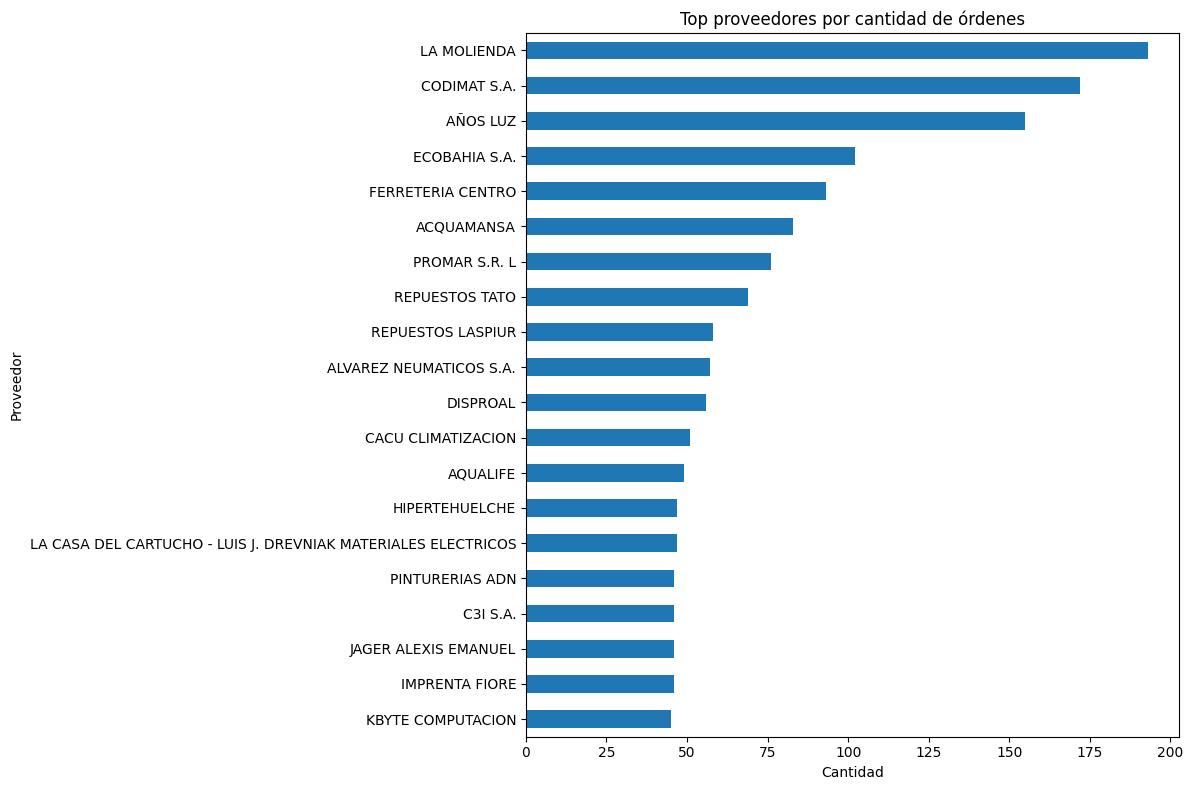

In [15]:
top_prov = df["proveedor"].value_counts().head(20)

plt.figure(figsize=(12,8))

top_prov.sort_values().plot(kind="barh")

plt.title("Top proveedores por cantidad de órdenes")
plt.xlabel("Cantidad")
plt.ylabel("Proveedor")

plt.tight_layout()

plt.show()

In [16]:
N = 20

top_proveedores = freq_prov.head(N).index

In [17]:
acumulada = freq_prov.cumsum() / freq_prov.sum()

N = (acumulada <= 0.60).sum()

print("N para cubrir 60%:", N)

N para cubrir 60%: 207


In [18]:
df["proveedor_frecuente"] = df["proveedor"].apply(
    lambda x: "Frecuente" if x in top_proveedores else "No frecuente"
)

In [19]:
print(df["proveedor_frecuente"].value_counts())

proveedor_frecuente
No frecuente    7022
Frecuente       1537
Name: count, dtype: int64


In [20]:
df["fecha"] = pd.to_datetime(
    df["fecha"],
    format="%d-%m-%Y"
)

In [21]:
df["mes"] = df["fecha"].dt.month
df["mes_nombre"] = df["fecha"].dt.month_name()

Se construyó un gráfico de líneas para visualizar la evolución mensual de las órdenes de compra a lo largo del año.

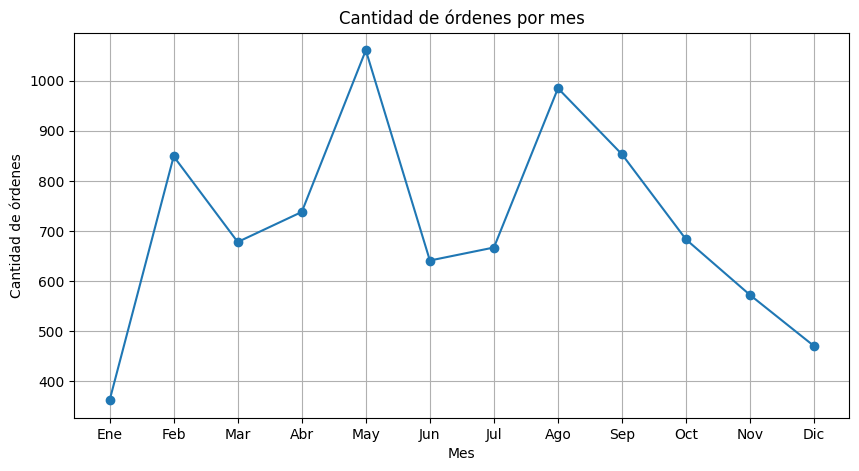

In [22]:
# Extraer mes numérico
df["mes"] = df["fecha"].dt.month

# Contar órdenes por mes
ordenes_mes = df.groupby("mes").size()

plt.figure(figsize=(10,5))

plt.plot(
    ordenes_mes.index,
    ordenes_mes.values,
    marker="o"
)

# Nombres de meses
meses = [
    "Ene", "Feb", "Mar", "Abr",
    "May", "Jun", "Jul", "Ago",
    "Sep", "Oct", "Nov", "Dic"
]

plt.xticks(range(1,13), meses)

plt.title("Cantidad de órdenes por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de órdenes")

plt.grid(True)

plt.show()


A partir de esta visualización, se observó que algunos meses concentraron una mayor cantidad de órdenes de compra que otros. En particular, mayo presentó el mayor número de órdenes emitidas durante 2024.

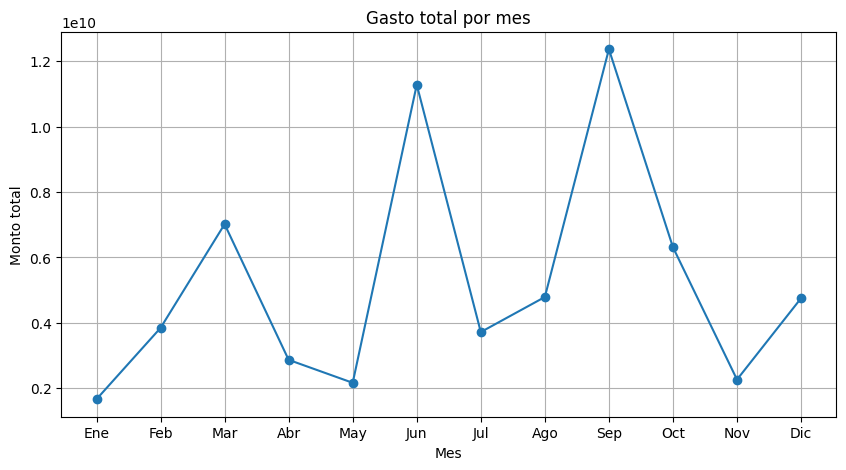

In [23]:
gasto_mes = df.groupby("mes")["importe"].sum()

plt.figure(figsize=(10,5))

plt.plot(
    gasto_mes.index,
    gasto_mes.values,
    marker="o"
)

plt.xticks(range(1,13), meses)

plt.title("Gasto total por mes")
plt.xlabel("Mes")
plt.ylabel("Monto total")

plt.grid(True)

plt.show()

In [24]:
df["año"] = df["fecha"].dt.year
df["mes"] = df["fecha"].dt.month
df["dia"] = df["fecha"].dt.day
df["dia_semana"] = df["fecha"].dt.dayofweek
df["trimestre"] = df["fecha"].dt.quarter

In [25]:
import numpy as np

df["log_importe"] = np.log(df["importe"])

Reducimos la cantidad de categorías distintas de la variable dependencia.

In [26]:
freq_dep = df["dependencia"].value_counts()

top_dependencias = freq_dep.head(20).index

df["dependencia_reducida"] = df["dependencia"].apply(
    lambda x: x if x in top_dependencias else "Otras"
)

Ese bloque transforma una variable categórica con muchísimos valores distintos (proveedor) en una variable binaria mucho más manejable para el modelo.

In [27]:
freq_prov = df["proveedor"].value_counts()

top_proveedores = freq_prov.head(20).index

df["proveedor_frecuente"] = df["proveedor"].apply(
    lambda x: 1 if x in top_proveedores else 0
)

1 → si el proveedor pertenece al top 20.

0 → si no pertenece.

In [28]:
df_modelo = pd.get_dummies(
    df,
    columns=[
        "dependencia_reducida",
        "dia_semana"
    ],
    drop_first=True
)

crea variables dummy, es decir, columnas binarias de 0 y 1

Las variables categóricas dependencia_reducida y dia_semana fueron transformadas mediante codificación dummy utilizando pd.get_dummies().

Este procedimiento convierte cada categoría en variables binarias (0/1), permitiendo que el modelo de regresión lineal procese información categórica.

In [29]:
df_modelo = df_modelo.drop(
    columns=[
        "fecha",
        "proveedor",
        "dependencia",
        "expediente"
    ]
)

Este bloque elimina columnas que no iban a utilizarse directamente en el modelo predictivo

Luego definimos variables predictoras y variables objetivo del modelo.

In [30]:
X = df_modelo.drop(columns=["importe", "log_importe"])
y = df_modelo["log_importe"]

Ese bloque divide los datos en conjuntos de entrenamiento y validación.

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Ese bloque crea y entrena el modelo de regresión lineal

In [32]:
from sklearn.linear_model import LinearRegression

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# asegurar mismas columnas
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

modelo = LinearRegression()

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# asegurar mismas columnas
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Ese bloque evalúa el desempeño del modelo sobre el conjunto de validación.

In [33]:
from sklearn.metrics import mean_absolute_error, r2_score

# Predicciones
y_pred = modelo.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R²:", r2)

MAE: 1.1582886091635938
R²: 0.18266532891661458


In [34]:
coeficientes = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": modelo.coef_
})

In [35]:
print(len(X.columns))
print(len(modelo.coef_))

33
43


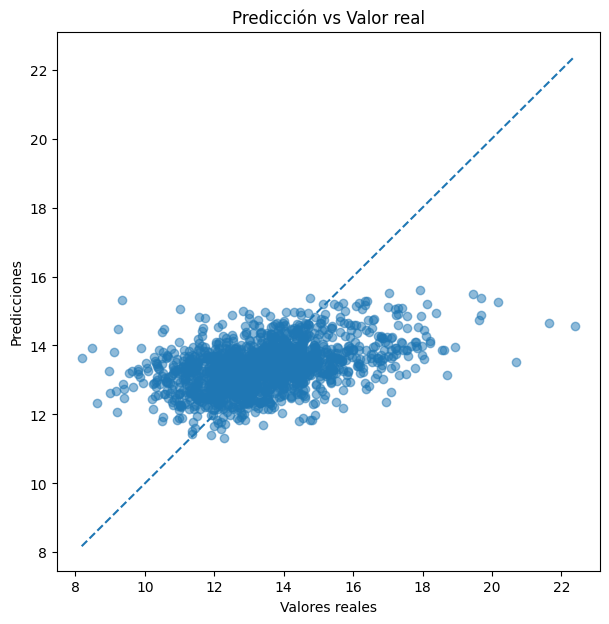

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")

plt.title("Predicción vs Valor real")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [37]:
from sklearn.metrics import mean_squared_error
import numpy as np

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# cantidad de observaciones y variables
n = X_test.shape[0]
p = X_test.shape[1]

# R2 ajustado
r2_ajustado = 1 - (1-r2)*(n-1)/(n-p-1)

print("RMSE:", rmse)
print("R² ajustado:", r2_ajustado)

RMSE: 1.543915246210584
R² ajustado: 0.16159495070523222


In [38]:
residuos = y_test - y_pred

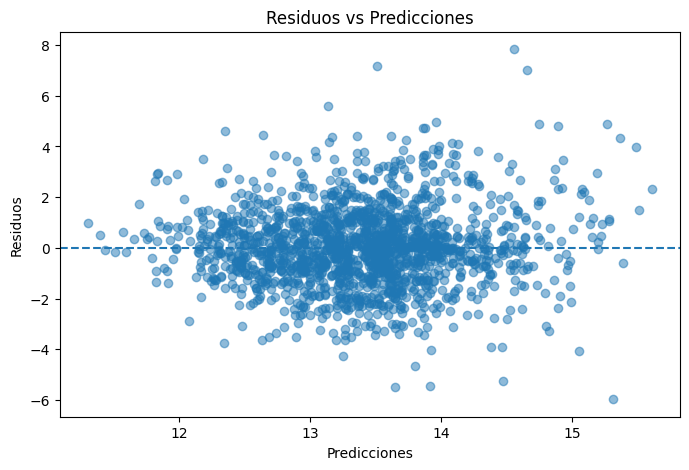

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuos, alpha=0.5)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos vs Predicciones")

plt.show()

# Finalmete, respondemos las Preguntas Bonobón

In [40]:
ordenes_por_mes = df.groupby("mes").size()

print(ordenes_por_mes)

mes
1      362
2      849
3      678
4      738
5     1061
6      641
7      667
8      985
9      853
10     683
11     572
12     470
dtype: int64


In [41]:
mes_max = ordenes_por_mes.idxmax()
cantidad_max = ordenes_por_mes.max()

print("Mes con más órdenes:", mes_max)
print("Cantidad de órdenes:", cantidad_max)

Mes con más órdenes: 5
Cantidad de órdenes: 1061


In [42]:
print(df.columns)

Index(['ejercicio', 'ordencompra', 'fecha', 'importe', 'proveedor',
       'dependencia', 'expediente', 'log_importe', 'dependencia_reducida',
       'proveedor_frecuente', 'mes', 'mes_nombre', 'año', 'dia', 'dia_semana',
       'trimestre'],
      dtype='str')


In [43]:
gasto_dependencia = df.groupby("dependencia")["importe"].sum()

print(gasto_dependencia.sort_values(ascending=False).head())

dependencia
SUBSECRETARIA DE AMBIENTE                2.084543e+10
DEP. PROYECTOS Y OBRAS                   5.908784e+09
DEP. VIALIDAD                            5.106130e+09
SUBSECRETARIA DE PROTECCION CIUDADANA    4.803266e+09
DEPARTAMENTO TALLERES Y MAESTRANZA       3.102099e+09
Name: importe, dtype: float64


In [44]:
dependencia_max = gasto_dependencia.idxmax()

print("Dependencia con mayor gasto:")
print(dependencia_max)

Dependencia con mayor gasto:
SUBSECRETARIA DE AMBIENTE


In [45]:
proveedor_max = df["proveedor"].value_counts().idxmax()

print(proveedor_max)

LA MOLIENDA
